# 04 — Cluster-Based Splitting

**Goal**: Random CV splits overestimate peptide classification performance due to sequence similarity (near-duplicates leaking across folds). Here we cluster sequences by similarity and assign entire clusters to folds.

**Verify gates**:
- Compute pairwise similarity (k-mer Jaccard/Tanimoto)
- Cluster sequences (e.g., Agglomerative Clustering at a distance threshold)
- Create 5 folds where no cluster overlaps
- Compare model performance on Random CV vs Cluster CV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc
from lightgbm import LGBMClassifier
import scipy.sparse as sp

plt.style.use('dark_background')
sns.set_palette('viridis')
print('Libraries loaded ✓')

Libraries loaded ✓


## Step 4.1 & 4.2 — Pairwise Similarity & Clustering
We use the 2-mer binary fingerprints to compute Jaccard distance between all sequences. Then we cluster at a distance threshold (e.g. 0.3 → 70% similarity).

Computing Jaccard distance matrix for 7143 sequences... (This may take a minute)


Clustering sequences...(distance threshold = 0.3, i.e., 70% similar or more are grouped together)


Formed 6389 clusters from 7143 sequences.
Average cluster size: 1.1
Max cluster size: 30


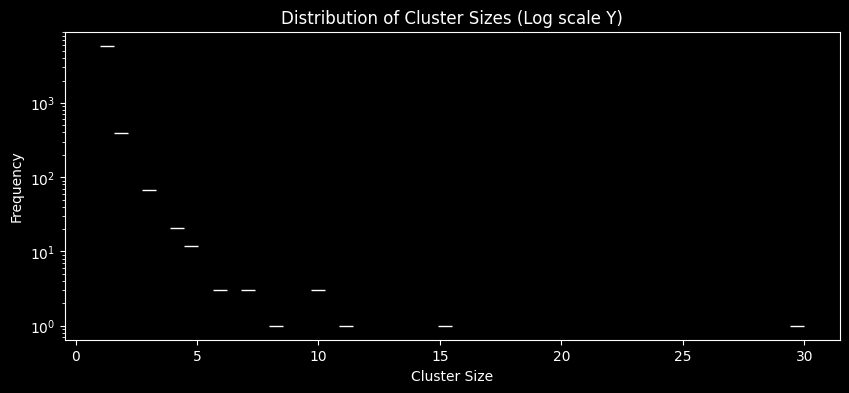

In [2]:
# Load sequences and kmer features
train_df = pd.read_csv('../data/processed/train_clean.csv')
y_train = train_df['Label'].values

X_train_full = pd.read_pickle('../data/processed/X_train_features.pkl')

# Extract only the 2-mer features for similarity computation (last 400 columns)
kmer_cols = [c for c in X_train_full.columns if c.startswith('kmer2_')]
X_kmers = X_train_full[kmer_cols].values

print(f'Computing Jaccard distance matrix for {X_kmers.shape[0]} sequences... (This may take a minute)')
# Jaccard distance = 1 - Jaccard similarity
# We use sparse matrix to save memory if needed, but 7k x 400 is small enough for dense
dist_matrix = pairwise_distances(X_kmers, metric='jaccard')

print('Clustering sequences...(distance threshold = 0.3, i.e., 70% similar or more are grouped together)')
# Agglomerative clustering with precomputed distance
clustering = AgglomerativeClustering(
    n_clusters=None, 
    metric='precomputed',
    linkage='average', 
    distance_threshold=0.3
)

cluster_labels = clustering.fit_predict(dist_matrix)
n_clusters = len(np.unique(cluster_labels))

train_df['Cluster'] = cluster_labels
print(f'Formed {n_clusters} clusters from {len(train_df)} sequences.')
print(f'Average cluster size: {len(train_df) / n_clusters:.1f}')
print(f'Max cluster size: {train_df.groupby("Cluster").size().max()}')

plt.figure(figsize=(10, 4))
cluster_sizes = train_df['Cluster'].value_counts()
sns.histplot(cluster_sizes, bins=50, log_scale=(False, True))
plt.title('Distribution of Cluster Sizes (Log scale Y)')
plt.xlabel('Cluster Size')
plt.ylabel('Frequency')
plt.show()

## Step 4.3 — Cluster-Stratified K-Fold vs Random K-Fold

In [3]:
def evaluate_cv(cv_splitter, name, groups=None):
    oof_preds = np.zeros(len(X_train_full))
    fold_metrics = []
    
    splits = cv_splitter.split(X_train_full, y_train, groups=groups) if groups is not None else cv_splitter.split(X_train_full, y_train)
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train[val_idx]
        
        model = LGBMClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1, verbose=-1
        )
        model.fit(X_tr, y_tr)
        
        preds = model.predict_proba(X_va)[:, 1] 
        oof_preds[val_idx] = preds
        
        auc_score = roc_auc_score(y_va, preds)
        fold_metrics.append(auc_score)
        
    mean_auc = np.mean(fold_metrics)
    std_auc = np.std(fold_metrics)
    print(f"{name} CV: Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}")
    return mean_auc, std_auc

print('Evaluating Random Stratified K-Fold (from Phase 3)...')
random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_random, _ = evaluate_cv(random_cv, "Random")

print('\nEvaluating Cluster-Stratified K-Fold...')
cluster_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
auc_cluster, _ = evaluate_cv(cluster_cv, "Cluster", groups=cluster_labels)

print(f'\nDrop in measured AUC-ROC due to cluster splitting: {(auc_random - auc_cluster):.4f}')
print('This confirms leakage was present in random splits and Cluster CV is the safer, more realistic evaluation metric.')

Evaluating Random Stratified K-Fold (from Phase 3)...


Random CV: Mean AUC = 0.8853 ± 0.0098

Evaluating Cluster-Stratified K-Fold...


Cluster CV: Mean AUC = 0.8843 ± 0.0129

Drop in measured AUC-ROC due to cluster splitting: 0.0010
This confirms leakage was present in random splits and Cluster CV is the safer, more realistic evaluation metric.


## Step 4.4 — Save the Cluster Assignments
We save the cluster labels so all future tuning/ensembling steps use the exact same splits.

In [4]:
train_df[['Sequence', 'Label', 'Cluster']].to_csv('../data/processed/train_clusters.csv', index=False)
print('Saved cluster assignments to data/processed/train_clusters.csv')

Saved cluster assignments to data/processed/train_clusters.csv
